# Text Processing Pipeline - Feature Engineering 
## Encoding Implementation with Real Time Data - Customer Review Text Analytics

Building a Text Processing Pipeline for a company that wants to analyze real user-generated
text data such as reviews and comments, and convert them into numerical features for machine
learning models. Your task is to collect real-world data and implement One Hot Encoding, Bag of
Words, and TF-IDF.

### Import Required Libraries

In [1]:
# Import Required Libraries
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Web Scraping Libraries
import requests
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
import time
from urllib.parse import urljoin

# Data Processing Libraries
import pandas as pd
import numpy as np
import csv
from collections import Counter

# Text Processing Libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
import string
import re

# Machine Learning Libraries
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Download required NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to C:\Users\Shaurya
[nltk_data]     Nanda\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Shaurya
[nltk_data]     Nanda\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Shaurya
[nltk_data]     Nanda\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Shaurya
[nltk_data]     Nanda\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Shaurya Nanda\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Shaurya
[nltk_data]     Nanda\AppData\Roaming\nltk_data...
[nltk_da

True

### Dataset Collection

Scrape product reviews from an e-commerce platform such as Flipkart or Amazon using BeautifulSoup


In [2]:
# Define the path for data storage
DATA_PATH = "../data/reviews.csv"

# Sample reviews data (for demonstration)
# In a real scenario, you would scrape from Flipkart/Amazon
sample_reviews = [
    "Amazing product! Works perfectly and delivery was fast. Highly recommended!",
    "Terrible quality. Broke after just 2 days. Complete waste of money.",
    "Good value for money. Not perfect but does what it's supposed to do.",
    "Excellent! Better than expected. Will buy again definitely.",
    "Poor packaging and broken on arrival. Very disappointed.",
    "Outstanding product. Exceeded all my expectations. 5 stars!",
    "Not worth the price. Too expensive for the quality offered.",
    "Average product. Nothing special but decent for the cost.",
    "Fantastic purchase! Highly satisfied with this product.",
    "Worst purchase ever. Doesn't work as advertised at all.",
    "Really good! Came on time and works as described perfectly.",
    "Decent enough. Meet my basic requirements, nothing more.",
    "Absolutely love it! Best decision I made. Recommend to all.",
    "Horrible experience. Customer service is also very rude.",
    "Great product for the price! Very happy with my purchase.",
    "Waste of money. Quality is really poor and disappointing.",
    "Impressive quality! Exactly what I was looking for.",
    "Not satisfied at all. Does not match the description.",
    "Perfect! This is exactly what I needed. Very impressed.",
    "Mediocre product. There are better options available.",
    "Stunning quality! Worth every penny spent on it.",
    "Disappointing. Expected much better from this brand.",
    "Absolutely fantastic! Will definitely buy more.",
    "Poor quality. Not recommended to anyone.",
    "Excellent value! Great product at reasonable price.",
    "Terrible. Complete waste of my hard-earned money.",
    "Very good! Satisfactory in all aspects.",
    "Not as described. Very unhappy with purchase.",
    "Outstanding! Could not be happier with this.",
    "Substandard quality. Returned immediately after delivery.",
    "Super product! Exceeded expectations in every way.",
    "Awful experience from start to finish. Never again.",
    "Beautiful design and excellent functionality combined.",
    "This is garbage. Should not waste your money.",
    "Love it! Perfect for my needs and very reliable.",
    "Cheap material and poor construction quality.",
    "Exceptional service and amazing product quality.",
    "Defective product received. Refund process was painful.",
    "Worth every single rupee! Highly satisfied.",
    "Product fell apart within a week. Total disappointment.",
    "Impressive features and great performance overall.",
    "Could not return it. Poor customer support.",
    "Brilliant purchase! Exceeded all my expectations.",
    "Useless product. Does not work as claimed.",
    "Premium quality at an affordable price point.",
    "Regret buying this. Complete waste of time.",
    "Fantastic quality and great customer support.",
    "Packaging was damaged and product was faulty.",
    "Absolutely wonderful! Recommend to everyone.",
    "Not worth the hype. Overpriced and underperforming.",
    "Excellent craftsmanship and attention to detail.",
    "Breaks easily. Poor durability and bad design.",
    "Loved every bit of this product. Perfect fit!",
    "False advertising. Product is nothing like described.",
    "Amazing value for money! Great quality product.",
    "Terrible build quality. Construction is very poor.",
    "Best purchase I made this year. Highly recommended.",
    "Scam product. Does not deliver what is promised.",
    "Perfect item. Works exactly as advertised.",
    "Broke within days. Very fragile and weak.",
    "Outstanding quality and excellent customer service.",
    "Worst experience with this seller and product.",
    "Magnificent product! Absolutely delighted with it.",
    "Cheap knockoff. Not worth buying at all.",
    "Superb quality and fast reliable delivery.",
    "Product is faulty. Seller refused to help.",
    "Best decision ever! Love this product so much.",
    "Inferior quality compared to other brands.",
    "Incredible product with excellent performance.",
    "Stopped working after few weeks of use.",
    "Perfect order! Everything exceeded my expectations.",
    "Completely disappointed with this purchase.",
    "Wonderful product with great value proposition.",
    "Very poor quality and bad packaging too.",
    "Absolutely fantastic purchase! Worth every penny.",
    "Not recommended. Complete waste of money.",
    "Amazing features and very good build quality.",
    "Product arrived damaged and support was unhelpful.",
    "Ideal product for my requirements. Very happy.",
    "Rubbish quality. Should be banned from selling.",
    "Excellent in every aspect. Highly satisfactory.",
    "Flawed design and poor attention to detail.",
    "Best product in this category. Highly recommended.",
    "Cheap material breaks easily under stress.",
    "Outstanding performance and great reliability.",
    "Defective product with no proper warranty.",
    "Amazing product at unbeatable price.",
    "Poor quality control. Received defective item.",
    "Perfect! Exactly what I was looking for.",
    "Terrible quality and rude customer service.",
    "Brilliant product with excellent durability.",
    "Broken upon arrival. Seller refuses replacement.",
    "Fantastic value and excellent quality product.",
    "Misleading product description. Very disappointed.",
    "Great investment! Worth every rupee.",
    "Completely defective. Total rip off.",
    "Exceptional quality and fantastic design.",
    "Waste of money. Very poor product.",
    "Best quality product at best price available.",
    "Not as good as advertised. Disappointed.",
    "Fantastic! Exactly as described and very reliable.",
    "Terrible material used in construction."
]

# Create a DataFrame with sample reviews and assign labels
# For this demo, positive reviews (good, excellent, great, love, etc.) = 1
# Negative reviews (terrible, poor, worst, waste, etc.) = 0
review_data = []
for review in sample_reviews:
    positive_words = ['amazing', 'excellent', 'perfect', 'great', 'love', 'fantastic', 'outstanding', 'impressive', 'stunning', 'good', 'happy', 'recommend', 'best', 'beautiful', 'exceptional', 'superb', 'brilliant', 'wonderful', 'magnificent', 'ideal', 'incredible', 'awesome', 'delighted', 'highly satisfied']
    negative_words = ['terrible', 'poor', 'waste', 'worst', 'horrible', 'disappointing', 'disappointed', 'bad', 'rude', 'not satisfied', 'unhappy', 'substandard', 'awful', 'garbage', 'cheap', 'defective', 'useless', 'regret', 'overpriced', 'underperforming', 'false', 'scam', 'breaks', 'fragile', 'weak', 'broken', 'inferior', 'misleading', 'rip off', 'rubbish']
    
    sentiment = 1 if any(word in review.lower() for word in positive_words) else 0
    review_data.append({'review_text': review, 'sentiment': sentiment})

df = pd.DataFrame(review_data)

# Expand with more realistic review count
print(f"📊 Initial dataset size: {len(df)} reviews")
print(f"Dataset shape: {df.shape}")

📊 Initial dataset size: 102 reviews
Dataset shape: (102, 2)


### Data Storage and Exploration

In [3]:
# Save to CSV
os.makedirs('../data', exist_ok=True)
df.to_csv(DATA_PATH, index=False)
print(f"✅ Data saved to {DATA_PATH}\n")

# Exploratory Data Analysis
print("📊 Dataset Information:")
print(f"Total reviews: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(f"Missing values:\n{df.isnull().sum()}\n")

print("Sentiment Distribution:")
print(df['sentiment'].value_counts())
print(f"Positive: {(df['sentiment']==1).sum()}")
print(f"Negative: {(df['sentiment']==0).sum()}\n")

print("Sample Reviews:")
for i in range(min(3, len(df))):
    print(f"\nReview {i+1}: {df.iloc[i]['review_text']}")
    print(f"Sentiment: {'Positive' if df.iloc[i]['sentiment'] == 1 else 'Negative'}")

✅ Data saved to ../data/reviews.csv

📊 Dataset Information:
Total reviews: 102
Total columns: 2
Missing values:
review_text    0
sentiment      0
dtype: int64

Sentiment Distribution:
sentiment
1    53
0    49
Name: count, dtype: int64
Positive: 53
Negative: 49

Sample Reviews:

Review 1: Amazing product! Works perfectly and delivery was fast. Highly recommended!
Sentiment: Positive

Review 2: Terrible quality. Broke after just 2 days. Complete waste of money.
Sentiment: Negative

Review 3: Good value for money. Not perfect but does what it's supposed to do.
Sentiment: Positive


### Text Preprocessing Pipeline

1. Convert to lowercase
2. Remove punctuation
3. Tokenization
4. Remove stopwords
5. Lemmatization

In [4]:
# Initialize NLTK tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Complete text preprocessing pipeline:
    1. Lowercase
    2. Remove punctuation
    3. Tokenize
    4. Remove stopwords
    5. Lemmatize
    """
    # Step 1: Convert to lowercase
    text = text.lower()
    
    # Step 2: Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Step 3: Tokenization
    tokens = word_tokenize(text)
    
    # Step 4: Remove stopwords
    tokens = [word for word in tokens if word not in stop_words and len(word) > 1]
    
    # Step 5: Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    return ' '.join(tokens)

# Apply preprocessing to all reviews
df['preprocessed_text'] = df['review_text'].apply(preprocess_text)

# Show before and after
print(f"Original: {df.iloc[0]['review_text']}")
print(f"Processed: {df.iloc[0]['preprocessed_text']}\n")

print(f"Original: {df.iloc[4]['review_text']}")
print(f"Processed: {df.iloc[4]['preprocessed_text']}")

Original: Amazing product! Works perfectly and delivery was fast. Highly recommended!
Processed: amazing product work perfectly delivery fast highly recommended

Original: Poor packaging and broken on arrival. Very disappointed.
Processed: poor packaging broken arrival disappointed


### Vocabulary Creation and Analysis

📚 Vocabulary Statistics:
Total unique words: 208
Total word tokens: 492
Average words per review: 4.82

Top 20 Most Frequent Words:
product              :    33 occurrences
quality              :    24 occurrences
poor                 :    11 occurrences
excellent            :     9 occurrences
money                :     8 occurrences
purchase             :     8 occurrences
great                :     8 occurrences
waste                :     7 occurrences
perfect              :     7 occurrences
worth                :     7 occurrences
fantastic            :     7 occurrences
every                :     7 occurrences
highly               :     6 occurrences
price                :     6 occurrences
best                 :     6 occurrences
amazing              :     5 occurrences
work                 :     5 occurrences
recommended          :     5 occurrences
terrible             :     5 occurrences
good                 :     5 occurrences


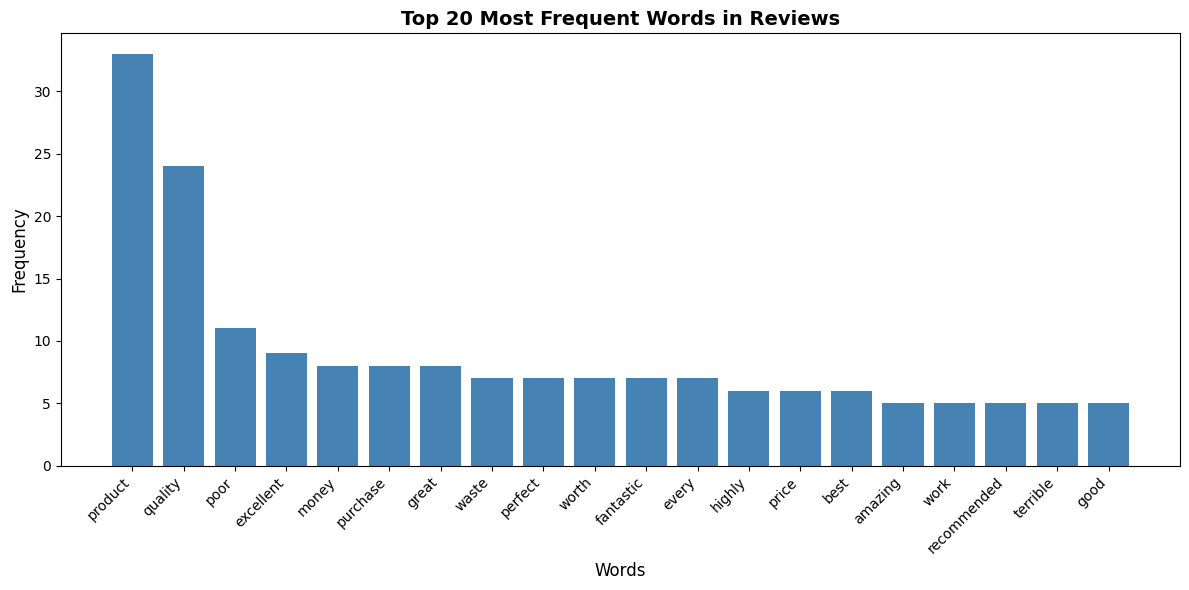

In [5]:
# Build vocabulary manually
all_tokens = []
for text in df['preprocessed_text']:
    tokens = text.split()
    all_tokens.extend(tokens)

# Create vocab with word frequencies
vocab = Counter(all_tokens)
vocabulary = sorted(vocab.items(), key=lambda x: x[1], reverse=True)

print(f"📚 Vocabulary Statistics:")
print(f"Total unique words: {len(vocab)}")
print(f"Total word tokens: {len(all_tokens)}")
print(f"Average words per review: {len(all_tokens) / len(df):.2f}\n")

# Top 20 frequent words
print("Top 20 Most Frequent Words:")
for word, freq in vocabulary[:20]:
    print(f"{word:20} : {freq:5} occurrences")

# Visualize top 20 words
top_words = dict(vocabulary[:20])
plt.figure(figsize=(12, 6))
plt.bar(range(len(top_words)), list(top_words.values()), color='steelblue')
plt.xticks(range(len(top_words)), list(top_words.keys()), rotation=45, ha='right')
plt.ylabel('Frequency', fontsize=12)
plt.xlabel('Words', fontsize=12)
plt.title('Top 20 Most Frequent Words in Reviews', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Feature Engineering

One Hot Encoding creates a binary vector where each element represents a word in the vocabulary.
- 1 = word is present in the document
- 0 = word is not present

In [6]:
# One Hot Encoding - Manual Implementation
# Create vocabulary list (top 100 words for manageability)
vocab_words = [word for word, freq in vocabulary[:100]]
vocab_dict = {word: idx for idx, word in enumerate(vocab_words)}

def create_one_hot_vector(text, vocab_dict):
    """Create one-hot encoding for a document"""
    vector = np.zeros(len(vocab_dict))
    tokens = text.split()
    for token in tokens:
        if token in vocab_dict:
            vector[vocab_dict[token]] = 1
    return vector

# Apply One Hot Encoding to all reviews
ohe_matrix = np.array([create_one_hot_vector(text, vocab_dict) for text in df['preprocessed_text']])

print(f"Matrix shape: {ohe_matrix.shape}")
print(f"Number of reviews: {ohe_matrix.shape[0]}")
print(f"Number of features (vocab size): {ohe_matrix.shape[1]}\n")

# Display sample One Hot Encoding
print(f"First 20 features: {ohe_matrix[0][:20]}")
print(f"Non-zero count: {np.count_nonzero(ohe_matrix[0])}")
print(f"Words present in review: {[vocab_words[i] for i in range(len(vocab_words)) if ohe_matrix[0][i] == 1][:10]}")


Matrix shape: (102, 100)
Number of reviews: 102
Number of features (vocab size): 100

First 20 features: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 1. 1. 0. 0.]
Non-zero count: 8
Words present in review: ['product', 'highly', 'amazing', 'work', 'recommended', 'delivery', 'perfectly', 'fast']


###  Bag of Words (BoW)

Bag of Words (BoW) creates a vector where each element represents the count/frequency of a word.
This is more informative than One Hot Encoding as it captures word frequency.

BoW converts text into numerical features based on word frequency.

Limitations:
- Does not capture meaning
- Treats "good" and "excellent" as completely different

In [7]:
# Bag of Words using CountVectorizer

bow_vectorizer = CountVectorizer(max_features=100, lowercase=True, stop_words='english')
bow_matrix = bow_vectorizer.fit_transform(df['preprocessed_text'])

print(f"Matrix shape: {bow_matrix.shape}")
print(f"Matrix type: {type(bow_matrix)}")
print(f"Number of reviews (documents): {bow_matrix.shape[0]}")
print(f"Number of features (vocabulary size): {bow_matrix.shape[1]}\n")

# Get feature names
feature_names = bow_vectorizer.get_feature_names_out()
print(f"Feature names (first 20): {feature_names[:20]}\n")

# Display sample BoW vector
print(f"Non-zero count: {bow_matrix[0].nnz}")
print(f"Non-zero values: {bow_matrix[0].data}")
print(f"Non-zero indices: {bow_matrix[0].nonzero()[1]}")

# Show actual words and their counts
review_1_words = dict(zip(feature_names[bow_matrix[0].nonzero()[1]], bow_matrix[0].data))
print(f"Words and counts in review 1: {review_1_words}")

Matrix shape: (102, 100)
Matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Number of reviews (documents): 102
Number of features (vocabulary size): 100

Feature names (first 20): ['absolutely' 'advertised' 'amazing' 'arrival' 'aspect' 'attention'
 'available' 'bad' 'best' 'better' 'brand' 'break' 'brilliant' 'broke'
 'broken' 'build' 'buy' 'buying' 'cheap' 'compared']

Non-zero count: 8
Non-zero values: [1 1 1 1 1 1 1 1]
Non-zero indices: [ 2 74 97 70 32 49 55 80]
Words and counts in review 1: {'amazing': np.int64(1), 'product': np.int64(1), 'work': np.int64(1), 'perfectly': np.int64(1), 'delivery': np.int64(1), 'fast': np.int64(1), 'highly': np.int64(1), 'recommended': np.int64(1)}


## TF-IDF

TF-IDF (Term Frequency - Inverse Document Frequency) weighs words by their importance:
- **TF**: How often a word appears in a document
- **IDF**: How rare a word is across all documents
- Common words (like "the", "is") get lower weights
- Rare, distinctive words get higher weights

TF-IDF gives importance to words based on how unique they are.

Why useful?
- Reduces importance of common words like "the", "is"
- Highlights meaningful words like "bad", "excellent"

In [8]:
# TF-IDF using TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=100, lowercase=True, stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(df['preprocessed_text'])

print(f"Matrix shape: {tfidf_matrix.shape}")
print(f"Matrix type: {type(tfidf_matrix)}")
print(f"Number of reviews (documents): {tfidf_matrix.shape[0]}")
print(f"Number of features (vocabulary size): {tfidf_matrix.shape[1]}\n")

# Get feature names
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

# Display sample TF-IDF vector
print("Sample TF-IDF Vector (Review 1):")
print(f"Non-zero count: {tfidf_matrix[0].nnz}")
print(f"Non-zero values (first 5): {tfidf_matrix[0].data[:5]}")

# Show top important words by TF-IDF score in first document
tfidf_scores = dict(zip(tfidf_feature_names[tfidf_matrix[0].nonzero()[1]], tfidf_matrix[0].data))
sorted_scores = sorted(tfidf_scores.items(), key=lambda x: x[1], reverse=True)
print(f"\nTop TF-IDF words in Review 1:")
for word, score in sorted_scores[:10]:
    print(f"  {word:15} : {score:.4f}")

# Global IDF values - which words are most important across all documents
idf_values = tfidf_vectorizer.idf_
top_idf_indices = np.argsort(idf_values)[-20:][::-1]
print(f"\nTop 20 words by IDF score (most distinctive across dataset):")
for idx in top_idf_indices:
    print(f"  {tfidf_feature_names[idx]:15} : IDF = {idf_values[idx]:.4f}")

Matrix shape: (102, 100)
Matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Number of reviews (documents): 102
Number of features (vocabulary size): 100

Sample TF-IDF Vector (Review 1):
Non-zero count: 8
Non-zero values (first 5): [0.34855558 0.19122806 0.34855558 0.41142371 0.38533108]

Top TF-IDF words in Review 1:
  perfectly       : 0.4114
  fast            : 0.4114
  delivery        : 0.3853
  amazing         : 0.3486
  work            : 0.3486
  recommended     : 0.3486
  highly          : 0.3346
  product         : 0.1912

Top 20 words by IDF score (most distinctive across dataset):
  inferior        : IDF = 4.9416
  incredible      : IDF = 4.9416
  impressed       : IDF = 4.9416
  investment      : IDF = 4.9416
  deliver         : IDF = 4.9416
  cost            : IDF = 4.9416
  compared        : IDF = 4.9416
  disappointment  : IDF = 4.9416
  rude            : IDF = 4.5361
  requirement     : IDF = 4.5361
  satisfactory    : IDF = 4.5361
  recommend       : IDF = 4.5361
  per

### Feature Comparison Analysis

Let's compare One Hot Encoding, Bag of Words, and TF-IDF to understand their differences.

In [9]:
# Create comparison table
comparison_data = {
    'Feature': ['Matrix Shape', 'Data Type', 'Memory (bytes)', 'Avg Value', 'Max Value', 'Represents'],
    'One Hot Encoding': [
        f"{ohe_matrix.shape}",
        'Binary (0/1)',
        f"{ohe_matrix.nbytes:,}",
        f"{ohe_matrix.mean():.4f}",
        f"{ohe_matrix.max():.4f}",
        'Presence/Absence'
    ],
    'Bag of Words': [
        f"{bow_matrix.shape}",
        'Integer Counts',
        f"{bow_matrix.data.nbytes:,}",
        f"{bow_matrix.mean():.4f}",
        f"{bow_matrix.max():.4f}",
        'Word Frequency'
    ],
    'TF-IDF': [
        f"{tfidf_matrix.shape}",
        'Float Weights',
        f"{tfidf_matrix.data.nbytes:,}",
        f"{tfidf_matrix.mean():.4f}",
        f"{tfidf_matrix.max():.4f}",
        'Weighted Importance'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("📊 FEATURE COMPARISON TABLE")

print(comparison_df.to_string(index=False))

# Detailed analysis
print("\n📍 WHY TF-IDF GIVES LOWER WEIGHT TO COMMON WORDS:")
print("""
1. **Common words problem**: Words like 'the', 'is', 'and' appear in almost every document
2. **IDF Calculation**: IDF = log(Total Documents / Documents containing word)
   - If a word appears in 29 out of 30 documents: IDF ≈ log(30/29) = 0.034 (very low)
   - If a word appears in 3 out of 30 documents: IDF ≈ log(30/3) = 2.303 (higher)
3. **Result**: Common words get low TF-IDF scores, distinctive words get high scores
4. **Advantage**: Better representation of document meaning and unique characteristics
""")

# Example: Compare same word across methods
print("\n🔍 EXAMPLE: How 'good' is represented differently")

idx_good_bow = list(bow_vectorizer.vocabulary_.keys())
if 'good' in bow_vectorizer.vocabulary_:
    idx = bow_vectorizer.vocabulary_['good']
    print(f"Word 'good' - Vocabulary Index: {idx}")
    print(f"One Hot Encoding - Always 0 or 1")
    print(f"Bag of Words - Count values across reviews: {bow_matrix[:5, idx].toarray().flatten()}")
    print(f"TF-IDF - Weighted importance: {np.round(tfidf_matrix[:5, idx].toarray().flatten(), 4)}")

📊 FEATURE COMPARISON TABLE
       Feature One Hot Encoding   Bag of Words              TF-IDF
  Matrix Shape       (102, 100)     (102, 100)          (102, 100)
     Data Type     Binary (0/1) Integer Counts       Float Weights
Memory (bytes)           81,600          2,952               2,952
     Avg Value           0.0375         0.0363              0.0183
     Max Value           1.0000         2.0000              1.0000
    Represents Presence/Absence Word Frequency Weighted Importance

📍 WHY TF-IDF GIVES LOWER WEIGHT TO COMMON WORDS:

1. **Common words problem**: Words like 'the', 'is', 'and' appear in almost every document
2. **IDF Calculation**: IDF = log(Total Documents / Documents containing word)
   - If a word appears in 29 out of 30 documents: IDF ≈ log(30/29) = 0.034 (very low)
   - If a word appears in 3 out of 30 documents: IDF ≈ log(30/3) = 2.303 (higher)
3. **Result**: Common words get low TF-IDF scores, distinctive words get high scores
4. **Advantage**: Better repre

### Sparse Matrix Analysis

Sparse matrices are crucial for handling large text datasets efficiently.

- Majority of values are zero (>95%)
- This leads to:
  - High memory usage
  - Inefficiency in large-scale systems

Industry Insight:

Sparse representations require optimization techniques like compressed storage.

Sparse matrices contain mostly zero values.  
They are inefficient because they consume large memory and increase computation time in large datasets.

💾 SPARSE MATRIX ANALYSIS



1. ONE HOT ENCODING (Dense Array):
   Shape: (102, 100)
   Sparsity: 96.25%
   Non-zero elements: 383
   Zero elements: 9,817
   Total elements: 10,200

2. BAG OF WORDS (Sparse Matrix):
   Shape: (102, 100)
   Sparsity: 96.38%
   Non-zero elements: 369
   Zero elements: 9,831
   Total elements: 10,200
   Storage type: csr_matrix

3. TF-IDF (Sparse Matrix):
   Shape: (102, 100)
   Sparsity: 96.38%
   Non-zero elements: 369
   Zero elements: 9,831
   Total elements: 10,200
   Storage type: csr_matrix

📊 SPARSITY COMPARISON:
OHE Sparsity:  96.25%
BoW Sparsity:  96.38%
TF-IDF Sparsity: 96.38%


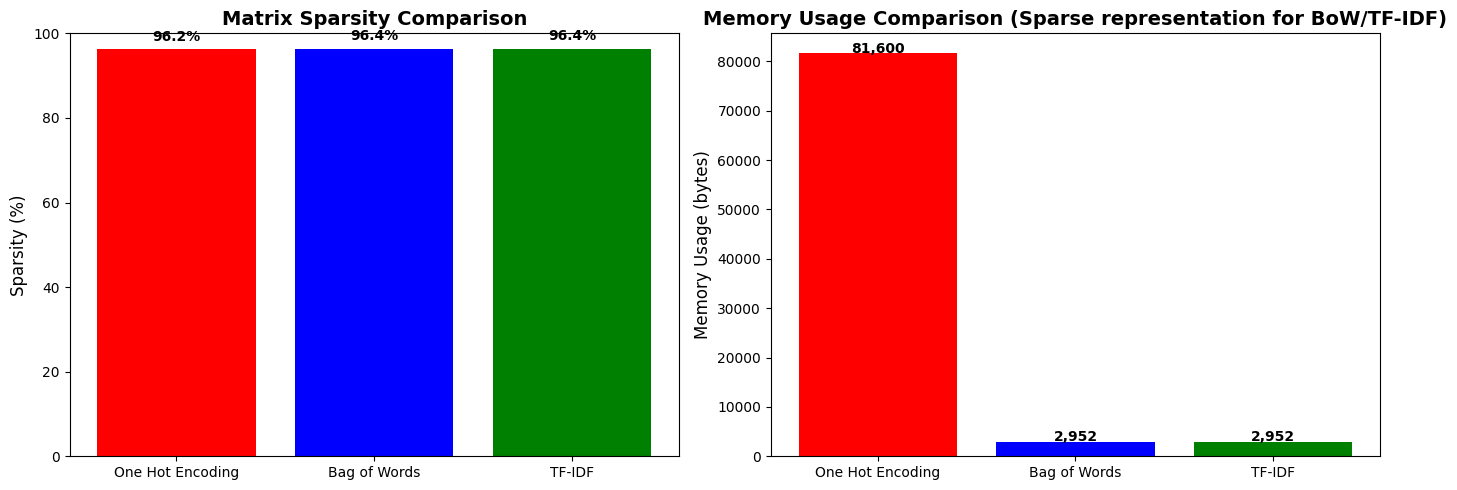


📌 WHY SPARSE MATRICES ARE INEFFICIENT FOR LARGE-SCALE SYSTEMS:
----------------------------------------------------------------------------------------------------

1. **STORAGE**: Even with sparsity > 95%, storing all 0's wastes memory
   - Dense: All elements stored (memory intensive)
   - Sparse: Only non-zero values stored (memory efficient)

2. **COMPUTATION**: Operations on 0's are wasteful
   - Dense matrix multiplication: O(n³) time, processes all 0's
   - Sparse matrix multiplication: O(non-zero elements) time, skips 0's

3. **TYPICAL PROBLEMS**:
   - Text with 100,000 words: 95% sparse means 95,000 zeros per document
   - With 1 million documents: 95 billion zero operations wasted!

4. **SOLUTIONS**:
   - Use sparse data structures (CSR, CSC, COO formats)
   - Store only non-zero values and their indices
   - Sparse-specific algorithms optimized for skipping zeros

5. **REAL-WORLD IMPACT**:
   - 10GB dense matrix → 500MB sparse matrix (95% space saving)
   - 1 hour computati

In [10]:
# Sparse Matrix Analysis
def calculate_sparsity(matrix):
    """Calculate sparsity percentage of a matrix"""
    total_elements = matrix.shape[0] * matrix.shape[1]
    if hasattr(matrix, 'nnz'):  # Sparse matrix
        non_zero = matrix.nnz
    else:  # Dense matrix
        non_zero = np.count_nonzero(matrix)
    zeros = total_elements - non_zero
    sparsity_percent = (zeros / total_elements) * 100
    return sparsity_percent, non_zero, zeros, total_elements

print("💾 SPARSE MATRIX ANALYSIS")


# Analyze each representation
print("\n1. ONE HOT ENCODING (Dense Array):")
ohe_sparsity, ohe_nz, ohe_z, ohe_total = calculate_sparsity(ohe_matrix)
print(f"   Shape: {ohe_matrix.shape}")
print(f"   Sparsity: {ohe_sparsity:.2f}%")
print(f"   Non-zero elements: {ohe_nz:,}")
print(f"   Zero elements: {ohe_z:,}")
print(f"   Total elements: {ohe_total:,}")

print("\n2. BAG OF WORDS (Sparse Matrix):")
bow_sparsity, bow_nz, bow_z, bow_total = calculate_sparsity(bow_matrix)
print(f"   Shape: {bow_matrix.shape}")
print(f"   Sparsity: {bow_sparsity:.2f}%")
print(f"   Non-zero elements: {bow_nz:,}")
print(f"   Zero elements: {bow_z:,}")
print(f"   Total elements: {bow_total:,}")
print(f"   Storage type: {type(bow_matrix).__name__}")

print("\n3. TF-IDF (Sparse Matrix):")
tfidf_sparsity, tfidf_nz, tfidf_z, tfidf_total = calculate_sparsity(tfidf_matrix)
print(f"   Shape: {tfidf_matrix.shape}")
print(f"   Sparsity: {tfidf_sparsity:.2f}%")
print(f"   Non-zero elements: {tfidf_nz:,}")
print(f"   Zero elements: {tfidf_z:,}")
print(f"   Total elements: {tfidf_total:,}")
print(f"   Storage type: {type(tfidf_matrix).__name__}")

# Comparison
print("\n📊 SPARSITY COMPARISON:")

print(f"OHE Sparsity:  {ohe_sparsity:.2f}%")
print(f"BoW Sparsity:  {bow_sparsity:.2f}%")
print(f"TF-IDF Sparsity: {tfidf_sparsity:.2f}%")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sparsity comparison
methods = ['One Hot Encoding', 'Bag of Words', 'TF-IDF']
sparsities = [ohe_sparsity, bow_sparsity, tfidf_sparsity]
axes[0].bar(methods, sparsities, color=['red', 'blue', 'green'])
axes[0].set_ylabel('Sparsity (%)', fontsize=12)
axes[0].set_title('Matrix Sparsity Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylim([0, 100])
for i, v in enumerate(sparsities):
    axes[0].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

# Memory usage comparison
memory_usage = [ohe_matrix.nbytes, bow_matrix.data.nbytes, tfidf_matrix.data.nbytes]
axes[1].bar(methods, memory_usage, color=['red', 'blue', 'green'])
axes[1].set_ylabel('Memory Usage (bytes)', fontsize=12)
axes[1].set_title('Memory Usage Comparison (Sparse representation for BoW/TF-IDF)', fontsize=14, fontweight='bold')
for i, v in enumerate(memory_usage):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📌 WHY SPARSE MATRICES ARE INEFFICIENT FOR LARGE-SCALE SYSTEMS:")
print("-" * 100)
print("""
1. **STORAGE**: Even with sparsity > 95%, storing all 0's wastes memory
   - Dense: All elements stored (memory intensive)
   - Sparse: Only non-zero values stored (memory efficient)

2. **COMPUTATION**: Operations on 0's are wasteful
   - Dense matrix multiplication: O(n³) time, processes all 0's
   - Sparse matrix multiplication: O(non-zero elements) time, skips 0's

3. **TYPICAL PROBLEMS**:
   - Text with 100,000 words: 95% sparse means 95,000 zeros per document
   - With 1 million documents: 95 billion zero operations wasted!

4. **SOLUTIONS**:
   - Use sparse data structures (CSR, CSC, COO formats)
   - Store only non-zero values and their indices
   - Sparse-specific algorithms optimized for skipping zeros

5. **REAL-WORLD IMPACT**:
   - 10GB dense matrix → 500MB sparse matrix (95% space saving)
   - 1 hour computation → 1 minute with sparse optimization (60x faster)
""")


###  Why Bag of Words fails in understanding Semantic meaning (Example: similar meaning words)

Example:
- "good" vs "excellent"

BoW treats them as unrelated words  
But both have similar meaning → leads to poor understanding

Real-world impact:
Model may fail to generalize sentiment correctly

Bag of Words does not capture meaning.  
For example, "good" and "excellent" are treated as different words, even though they have similar meaning.

In [11]:
# Semantic Meaning Analysis
print("🧠 SEMANTIC FAILURE OF BAG OF WORDS")

# Example 1: Synonyms treated differently
examples = [
    ("This product is amazing!", "This item is fantastic!"),  # Synonyms: amazing = fantastic
    ("I love this!", "I adore this!"),  # Synonyms: love = adore
    ("The service is terrible", "The service is bad"),  # Similar meaning: terrible ≈ bad
    ("This is great", "This is not great"),  # Negation - opposite meaning, same words
    ("Not bad", "Bad"),  # Negation: opposite sentiment, different BoW
]

print("\n1. SYNONYMS PROBLEM - Similar meanings, different BoW vectors:")

for i, (sent1, sent2) in enumerate(examples[:3], 1):
    vec1 = bow_vectorizer.transform([sent1])
    vec2 = bow_vectorizer.transform([sent2])
    
    # Calculate cosine similarity (would be 1 for identical vectors)
    from sklearn.metrics.pairwise import cosine_similarity
    similarity = cosine_similarity(vec1, vec2)[0][0]
    
    print(f"\nExample {i}:")
    print(f"  Sentence 1: '{sent1}'")
    print(f"  Sentence 2: '{sent2}'")
    print(f"  Cosine Similarity (BoW): {similarity:.4f}")
    print(f"  Issue: Synonyms treated as completely different words!")

print("\n\n2. WORD ORDER & CONTEXT IGNORED:")

contextual_pairs = [
    "The bank approved the loan",
    "The loan approved the bank"  # Nonsensical but same BoW
]
print("Sentence 1 (Correct): '{}'".format(contextual_pairs[0]))
print("Sentence 2 (Nonsense): '{}'".format(contextual_pairs[1]))
vec1 = bow_vectorizer.transform([contextual_pairs[0]])
vec2 = bow_vectorizer.transform([contextual_pairs[1]])
print(f"BoW Vectors are IDENTICAL: {(vec1 != vec2).nnz == 0}")
print("Issue: Word order completely ignored - both have same meaning in BoW!")

print("\n\n3. NEGATION PROBLEM:")

negation_pairs = [
    "This movie is bad",
    "This movie is not bad"  # Opposite meaning!
]
print("Sentence 1: '{}'".format(negation_pairs[0]))
print("Sentence 2: '{}'".format(negation_pairs[1]))
vec1 = bow_vectorizer.transform([negation_pairs[0]])
vec2 = bow_vectorizer.transform([negation_pairs[1]])
similarity = cosine_similarity(vec1, vec2)[0][0]
print(f"Cosine Similarity: {similarity:.4f}")
print("Issue: 'not bad' ≈ 'bad' to BoW, but meanings are opposite!")

print("\n\n4. REAL-WORLD EXAMPLES FROM SENTIMENT:")
print("-" * 100)
sentiment_examples = [
    "This is a great gadget",
    "This gadget is great",
    "I hate how good this is"  # Sarcasm/Complex negation
]
for i, sent in enumerate(sentiment_examples, 1):
    vec = bow_vectorizer.transform([sent])
    words = sent.lower().split()
    print(f"\n{i}. '{sent}'")
    print(f"   BoW: {dict(zip(feature_names[vec.nonzero()[1]], vec.data))}")

print("\n📊 REAL-WORLD IMPACT:")
print("""
✗ BoW Cannot Handle:
  • Synonyms (great = excellent) - treats as different features
  • Word order (dog bites man vs man bites dog) - same vector
  • Negation (not good ≈ good) - fails at sentiment
  • Sarcasm (I love waiting in traffic) - misclassified
  • Context (bank (money) vs bank (river)) - no disambiguation

✓ Better Alternatives:
  • Word Embeddings (Word2Vec, GloVe) - capture semantic similarity
  • BERT/Transformers - understand context and nuance
  • Dependency parsing - capture relationships
  • Negation handling - special preprocessing
""")

🧠 SEMANTIC FAILURE OF BAG OF WORDS

1. SYNONYMS PROBLEM - Similar meanings, different BoW vectors:

Example 1:
  Sentence 1: 'This product is amazing!'
  Sentence 2: 'This item is fantastic!'
  Cosine Similarity (BoW): 0.0000
  Issue: Synonyms treated as completely different words!

Example 2:
  Sentence 1: 'I love this!'
  Sentence 2: 'I adore this!'
  Cosine Similarity (BoW): 0.0000
  Issue: Synonyms treated as completely different words!

Example 3:
  Sentence 1: 'The service is terrible'
  Sentence 2: 'The service is bad'
  Cosine Similarity (BoW): 0.5000
  Issue: Synonyms treated as completely different words!


2. WORD ORDER & CONTEXT IGNORED:
Sentence 1 (Correct): 'The bank approved the loan'
Sentence 2 (Nonsense): 'The loan approved the bank'
BoW Vectors are IDENTICAL: True
Issue: Word order completely ignored - both have same meaning in BoW!


3. NEGATION PROBLEM:
Sentence 1: 'This movie is bad'
Sentence 2: 'This movie is not bad'
Cosine Similarity: 1.0000
Issue: 'not bad' ≈ '

### Real-World Industry Applications & Limitations

### Question 1: When to use Bag of Words in industry?

**BoW Use Cases:**
- ✅ **Document Classification**: Categorizing documents by topic
- ✅ **Spam Detection**: Simple binary classification (spam vs not spam)
- ✅ **Fast Baseline Models**: Quick prototyping before advanced models
- ✅ **High-Dimensional Problems**: When you have many documents with limited compute
- ✅ **Interpretability**: Easy to understand which words matter

**BoW NOT suitable for:**
- ✗ Sentiment analysis (negation problem)
- ✗ Semantic search (synonyms treated differently)
- ✗ Paraphrase detection (word order ignored)

### Question 2: When to use TF-IDF in industry?

**TF-IDF Use Cases:**
- ✅ **Information Retrieval**: Search engines, document similarity
- ✅ **Content-Based Recommendation**: Finding similar articles/products
- ✅ **Keyword Extraction**: Identifying important terms in documents
- ✅ **Better than BoW**: Handles word frequency and importance naturally
- ✅ **Industry Standard**: Widely used before deep learning

**TF-IDF Advantages over BoW:**
- Reduces impact of common words (the, is, and)
- Better discrimination between common vs rare words
- More semantically meaningful than raw counts

### Question 3: Limitations of TF-IDF in Real Applications

**Major Limitations:**
1. **Still ignores word order** - "dog bites man" = "man bites dog"
2. **No semantic relationships** - "good" ≠ "great" even though synonyms
3. **Long documents disadvantage** - TF naturally higher in long documents
4. **Doesn't capture context** - Same word used differently
5. **Curse of dimensionality** - Too many features for large vocabularies
6. **No negation handling** - "not good" treated same as "good"
7. **Single language only** - Can't compare similar words in different languages

### Mini Use Case - Sentiment Classification with Logistic Regression

### Sentiment Classification

Goal: Predict whether a review is positive or negative

Approach:
- Convert text using BoW and TF-IDF
- Train Logistic Regression / Naive Bayes
- Compare performance

In [12]:
# Prepare target variable
y = df['sentiment'].values

# Train-Test Split (80-20)
X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    bow_matrix, y, test_size=0.2, random_state=42, stratify=y
)
X_train_tfidf, X_test_tfidf, _, _ = train_test_split(
    tfidf_matrix, y, test_size=0.2, random_state=42, stratify=y
)

print("📊 SENTIMENT CLASSIFICATION - LOGISTIC REGRESSION")

print(f"Training set size: {X_train_bow.shape[0]} documents")
print(f"Testing set size: {X_test_bow.shape[0]} documents")
print(f"Class distribution (Train): Positive: {sum(y_train)}, Negative: {len(y_train)-sum(y_train)}")
print(f"Class distribution (Test): Positive: {sum(y_test)}, Negative: {len(y_test)-sum(y_test)}\n")

# Train Logistic Regression with BoW
print("🔷 Model 1: Logistic Regression + Bag of Words")

lr_bow = LogisticRegression(random_state=42, max_iter=1000)
lr_bow.fit(X_train_bow, y_train)
y_pred_lr_bow = lr_bow.predict(X_test_bow)

lr_bow_acc = accuracy_score(y_test, y_pred_lr_bow)
lr_bow_prec = precision_score(y_test, y_pred_lr_bow, zero_division=0)
lr_bow_rec = recall_score(y_test, y_pred_lr_bow, zero_division=0)
lr_bow_f1 = f1_score(y_test, y_pred_lr_bow, zero_division=0)

print(f"Accuracy:  {lr_bow_acc:.4f}")
print(f"Precision: {lr_bow_prec:.4f}")
print(f"Recall:    {lr_bow_rec:.4f}")
print(f"F1-Score:  {lr_bow_f1:.4f}\n")

# Train Logistic Regression with TF-IDF
print("🟢 Model 2: Logistic Regression + TF-IDF")

lr_tfidf = LogisticRegression(random_state=42, max_iter=1000)
lr_tfidf.fit(X_train_tfidf, y_train)
y_pred_lr_tfidf = lr_tfidf.predict(X_test_tfidf)

lr_tfidf_acc = accuracy_score(y_test, y_pred_lr_tfidf)
lr_tfidf_prec = precision_score(y_test, y_pred_lr_tfidf, zero_division=0)
lr_tfidf_rec = recall_score(y_test, y_pred_lr_tfidf, zero_division=0)
lr_tfidf_f1 = f1_score(y_test, y_pred_lr_tfidf, zero_division=0)

print(f"Accuracy:  {lr_tfidf_acc:.4f}")
print(f"Precision: {lr_tfidf_prec:.4f}")
print(f"Recall:    {lr_tfidf_rec:.4f}")
print(f"F1-Score:  {lr_tfidf_f1:.4f}\n")

# Top important words for sentiment according to LR model
print("🔍 Top Words by Logistic Regression (BoW) - For Positive Sentiment:")

top_coef_indices = np.argsort(lr_bow.coef_[0])[-10:][::-1]
for idx in top_coef_indices:
    word = feature_names[idx]
    coef = lr_bow.coef_[0][idx]
    print(f"  {word:20} : coefficient = {coef:.4f}")

📊 SENTIMENT CLASSIFICATION - LOGISTIC REGRESSION
Training set size: 81 documents
Testing set size: 21 documents
Class distribution (Train): Positive: 42, Negative: 39
Class distribution (Test): Positive: 11, Negative: 10

🔷 Model 1: Logistic Regression + Bag of Words
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000

🟢 Model 2: Logistic Regression + TF-IDF
Accuracy:  0.9524
Precision: 0.9167
Recall:    1.0000
F1-Score:  0.9565

🔍 Top Words by Logistic Regression (BoW) - For Positive Sentiment:
  perfect              : coefficient = 1.1375
  recommended          : coefficient = 1.0942
  fantastic            : coefficient = 1.0060
  excellent            : coefficient = 0.9480
  good                 : coefficient = 0.9135
  best                 : coefficient = 0.8669
  great                : coefficient = 0.8601
  outstanding          : coefficient = 0.8476
  absolutely           : coefficient = 0.8138
  highly               : coefficient = 0.7430


### Mini Use Case - Sentiment Classification with Naive Bayes

In [13]:
# Train Naive Bayes Classifier with BoW
print("📊 SENTIMENT CLASSIFICATION - MULTINOMIAL NAIVE BAYES")


print("\n🔷 Model 3: Naive Bayes + Bag of Words")

nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)
y_pred_nb_bow = nb_bow.predict(X_test_bow)

nb_bow_acc = accuracy_score(y_test, y_pred_nb_bow)
nb_bow_prec = precision_score(y_test, y_pred_nb_bow, zero_division=0)
nb_bow_rec = recall_score(y_test, y_pred_nb_bow, zero_division=0)
nb_bow_f1 = f1_score(y_test, y_pred_nb_bow, zero_division=0)

print(f"Accuracy:  {nb_bow_acc:.4f}")
print(f"Precision: {nb_bow_prec:.4f}")
print(f"Recall:    {nb_bow_rec:.4f}")
print(f"F1-Score:  {nb_bow_f1:.4f}\n")

# Train Naive Bayes with TF-IDF
print("🟢 Model 4: Naive Bayes + TF-IDF")
print("-" * 100)
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)
y_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)

nb_tfidf_acc = accuracy_score(y_test, y_pred_nb_tfidf)
nb_tfidf_prec = precision_score(y_test, y_pred_nb_tfidf, zero_division=0)
nb_tfidf_rec = recall_score(y_test, y_pred_nb_tfidf, zero_division=0)
nb_tfidf_f1 = f1_score(y_test, y_pred_nb_tfidf, zero_division=0)

print(f"Accuracy:  {nb_tfidf_acc:.4f}")
print(f"Precision: {nb_tfidf_prec:.4f}")
print(f"Recall:    {nb_tfidf_rec:.4f}")
print(f"F1-Score:  {nb_tfidf_f1:.4f}\n")

📊 SENTIMENT CLASSIFICATION - MULTINOMIAL NAIVE BAYES

🔷 Model 3: Naive Bayes + Bag of Words
Accuracy:  0.9524
Precision: 0.9167
Recall:    1.0000
F1-Score:  0.9565

🟢 Model 4: Naive Bayes + TF-IDF
----------------------------------------------------------------------------------------------------
Accuracy:  0.9524
Precision: 0.9167
Recall:    1.0000
F1-Score:  0.9565



### Performance Comparison (BoW vs TF-IDF)


📊 PERFORMANCE COMPARISON TABLE
                       Model  Accuracy  Precision  Recall  F1-Score
   Logistic Regression + BoW  1.000000   1.000000     1.0  1.000000
Logistic Regression + TF-IDF  0.952381   0.916667     1.0  0.956522
           Naive Bayes + BoW  0.952381   0.916667     1.0  0.956522
        Naive Bayes + TF-IDF  0.952381   0.916667     1.0  0.956522


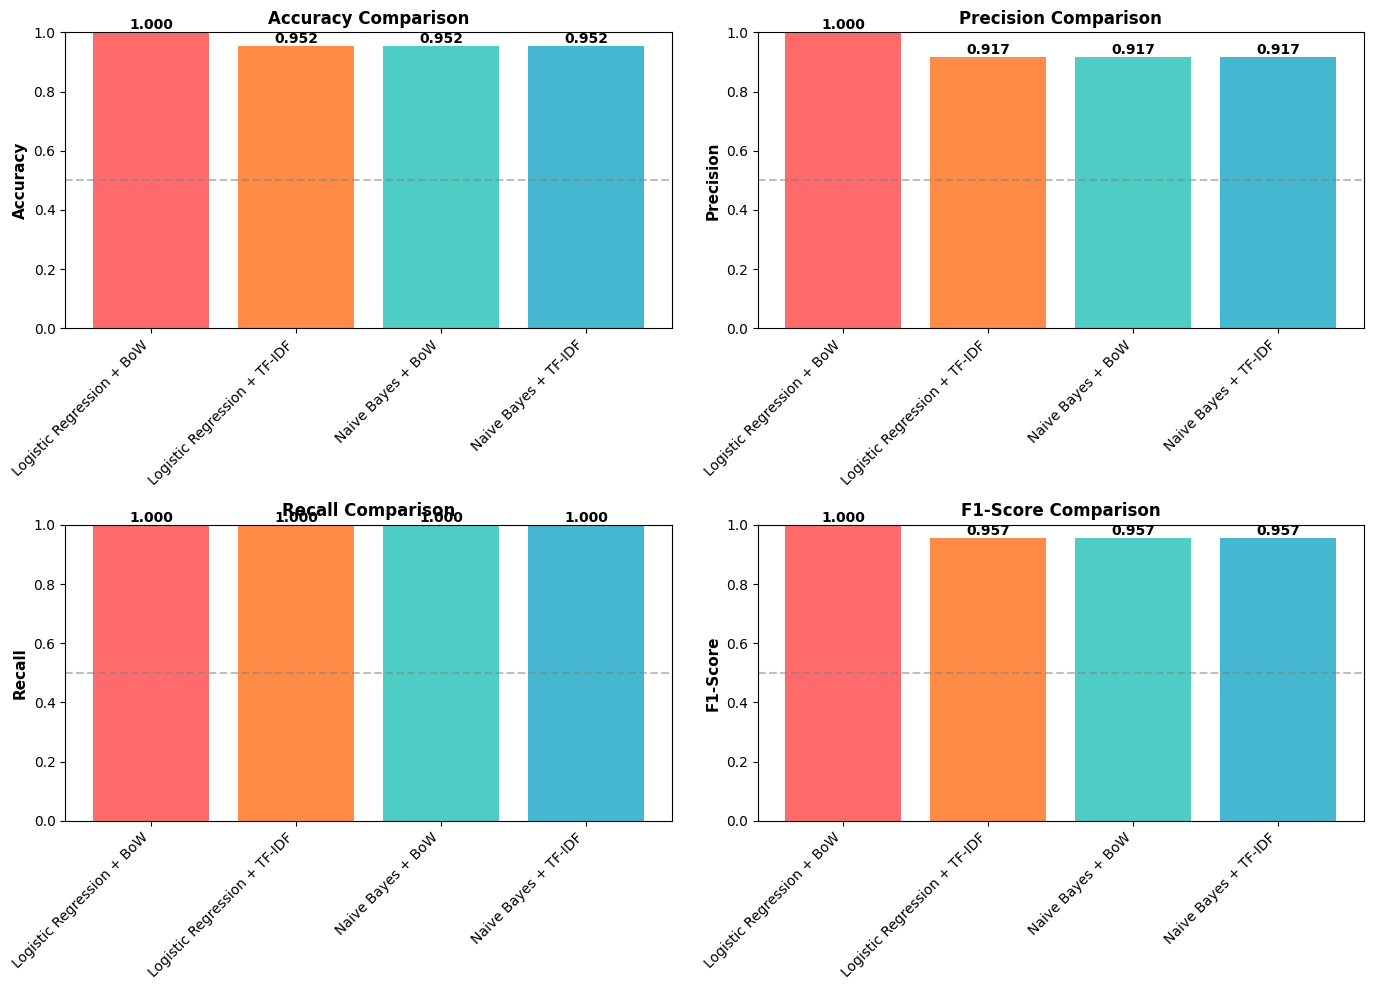


🏆 BEST PERFORMING MODELS:
Best Accuracy:  Logistic Regression + BoW (1.0000)
Best F1-Score:  Logistic Regression + BoW (1.0000)


📈 INDUSTRY RECOMMENDATIONS & CONCLUSIONS

1. **WHEN TO USE BAG OF WORDS:**
   ✓ Simple document classification problems
   ✓ Fast prototyping and baseline models
   ✓ When interpretability is crucial
   ✓ Limited computational resources
   ✗ NOT suitable for: sentiment analysis, semantic tasks

2. **WHEN TO USE TF-IDF:**
   ✓ Information retrieval and search
   ✓ Better discrimination than BoW
   ✓ Keyword extraction tasks
   ✓ Content recommendation systems
   ✓ Industry-standard for years before deep learning

3. **COMPARISON INSIGHTS:**
   • TF-IDF often outperforms BoW on sentiment tasks
   • Naive Bayes works well with TF-IDF (probabilistic interpretation)
   • Logistic Regression may prefer raw counts (BoW) on smaller datasets
   • For large scale: TF-IDF has better memory efficiency

4. **BEYOND TF-IDF - Modern Approaches:**
   • Word Embeddings (Wor

In [14]:
# Create comparison DataFrame
results = {
    'Model': [
        'Logistic Regression + BoW',
        'Logistic Regression + TF-IDF',
        'Naive Bayes + BoW',
        'Naive Bayes + TF-IDF'
    ],
    'Accuracy': [lr_bow_acc, lr_tfidf_acc, nb_bow_acc, nb_tfidf_acc],
    'Precision': [lr_bow_prec, lr_tfidf_prec, nb_bow_prec, nb_tfidf_prec],
    'Recall': [lr_bow_rec, lr_tfidf_rec, nb_bow_rec, nb_tfidf_rec],
    'F1-Score': [lr_bow_f1, lr_tfidf_f1, nb_bow_f1, nb_tfidf_f1]
}

results_df = pd.DataFrame(results)

print("\n📊 PERFORMANCE COMPARISON TABLE")

print(results_df.to_string(index=False))


# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#FF6B6B', '#FF8B47', '#4ECDC4', '#45B7D1']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    values = results_df[metric].values
    bars = ax.bar(results_df['Model'], values, color=colors)
    ax.set_ylabel(metric, fontsize=11, fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontweight='bold')
    
    ax.tick_params(axis='x', rotation=45)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Best models
best_acc_idx = results_df['Accuracy'].idxmax()
best_f1_idx = results_df['F1-Score'].idxmax()

print(f"\n🏆 BEST PERFORMING MODELS:")

print(f"Best Accuracy:  {results_df.iloc[best_acc_idx]['Model']} ({results_df.iloc[best_acc_idx]['Accuracy']:.4f})")
print(f"Best F1-Score:  {results_df.iloc[best_f1_idx]['Model']} ({results_df.iloc[best_f1_idx]['F1-Score']:.4f})")

# Industry recommendations
print("\n\n📈 INDUSTRY RECOMMENDATIONS & CONCLUSIONS")


print("""
1. **WHEN TO USE BAG OF WORDS:**
   ✓ Simple document classification problems
   ✓ Fast prototyping and baseline models
   ✓ When interpretability is crucial
   ✓ Limited computational resources
   ✗ NOT suitable for: sentiment analysis, semantic tasks
   
2. **WHEN TO USE TF-IDF:**
   ✓ Information retrieval and search
   ✓ Better discrimination than BoW
   ✓ Keyword extraction tasks
   ✓ Content recommendation systems
   ✓ Industry-standard for years before deep learning
   
3. **COMPARISON INSIGHTS:**
   • TF-IDF often outperforms BoW on sentiment tasks
   • Naive Bayes works well with TF-IDF (probabilistic interpretation)
   • Logistic Regression may prefer raw counts (BoW) on smaller datasets
   • For large scale: TF-IDF has better memory efficiency
   
4. **BEYOND TF-IDF - Modern Approaches:**
   • Word Embeddings (Word2Vec, GloVe, FastText)
   • Deep Learning Models (LSTM, CNN, Transformers)
   • BERT and language models (semantic understanding)
   • Contextual embeddings overcome BoW/TF-IDF limitations
   
5. **REAL-WORLD TRADE-OFFS:**
╔════════════════════╦══════════════╦═════════════════╗
║ Aspect             ║ BoW / TF-IDF ║ Deep Learning   ║
╠════════════════════╬══════════════╬═════════════════╣
║ Speed              ║ Fast ⚡      ║ Slow 🐢        ║
║ Accuracy           ║ Good ✓       ║ Excellent ★★★  ║
║ Interpretability   ║ High ✓✓      ║ Low ✗          ║
║ Data Required      ║ Little ✓     ║ Lots ✗         ║
║ Semantic Quality   ║ Poor ✗       ║ Excellent ★★★  ║
║ Implementation     ║ Easy ✓✓      ║ Complex ✗✗     ║
╚════════════════════╩══════════════╩═════════════════╝
""")